# KNN — Split Temporal alinhado ao XGBoost

Este notebook mantém a mesma lógica experimental do notebook de XGBoost:
- mesma base e target;
- mesma engenharia de features;
- mesmo split temporal em `2018-07-01`;
- mesmo target encoding suavizado;
- mesma normalização com `StandardScaler`;
- balanceamento com `RandomUnderSampler` aplicado somente aos dados de treinamento;
- atraso representado pela classe positiva `1`;
- `TimeSeriesSplit` com 5 folds;
- 50 trials do Optuna;
- otimização por PR-AUC;
- escolha do limiar por F1, com desempate por Recall e Precision;
- mesmas métricas de avaliação.

Os hiperparâmetros internos são próprios do KNN, pois parâmetros como `max_depth`, `learning_rate`, `gamma` e `n_estimators` pertencem ao XGBoost e não existem no KNN.

## Balanceamento

O `RandomUnderSampler` é aplicado **dentro de cada fold de treinamento**, depois da separação temporal.
A validação de cada fold permanece com a distribuição original. No treinamento final, somente
`X_train`/`y_train` são balanceados; `X_test`/`y_test` nunca são alterados.

Isso evita avaliar o modelo em uma distribuição artificial e reduz o risco de vazamento metodológico.


In [1]:
# Celula 1: prepara o ambiente de trabalho.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Balanceamento da classe minoritaria.
# RandomUnderSampler reduz a classe majoritaria SOMENTE no conjunto de treino.
try:
    from imblearn.under_sampling import RandomUnderSampler
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.under_sampling import RandomUnderSampler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
    log_loss,
    ConfusionMatrixDisplay,
)

# Instala automaticamente o Optuna apenas se ele nao estiver disponivel.
try:
    import optuna
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna

# Instala automaticamente o optuna-dashboard apenas se ele nao estiver disponivel.
try:
    import optuna_dashboard
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna-dashboard", "-q"])
    import optuna_dashboard

pd.set_option("display.max_columns", None)
print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Celula 2: leitura da base e preparo das variaveis de entrada.
# MESMA preparação usada no notebook do XGBoost.

csv_path = Path("../../tabela_final/table_orders_holidays_ecommerce_events.csv")
df = pd.read_csv(csv_path)

target_col = "delivered_on_time"
if target_col not in df.columns:
    raise ValueError(f"A coluna alvo '{target_col}' nao foi encontrada no CSV.")

# =====================================================================
# 1. ENGENHARIA DO SLA
# =====================================================================
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], utc=True)
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"], utc=True)
df["order_delivered_carrier_date"] = pd.to_datetime(df["order_delivered_carrier_date"], utc=True)

df["prazo_transportadora_dias"] = (
    df["order_estimated_delivery_date"] - df["order_delivered_carrier_date"]
).dt.days

df = df.dropna(subset=["prazo_transportadora_dias"]).copy()

# Sazonalidade
df["purchase_month"] = df["order_purchase_timestamp"].dt.month

# =====================================================================
# 1b. FEATURES DE INTERACAO
# =====================================================================
df["prazo_por_km"] = df["prazo_transportadora_dias"] / (df["distance_km"] + 1)
df["frete_por_kg"] = df["freight_value"] / (df["product_weight_g"] / 1000 + 0.1)
df["densidade_produto"] = df["product_weight_g"] / (df["volume_cm3"] + 1)

# =====================================================================
# 2. ORDENACAO CRONOLOGICA
# =====================================================================
df = df.sort_values("order_delivered_carrier_date").reset_index(drop=True)

date_col = df["order_delivered_carrier_date"].copy()
split_date = pd.to_datetime("2018-07-01", utc=True)

leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]
leakage_cols = [c for c in leakage_candidates if c in df.columns]

feature_cols = [c for c in df.columns if c != target_col and c not in leakage_cols]
X = df[feature_cols].copy()

# Igual ao XGBoost: atraso = 1; no prazo = 0.
y = (~df[target_col].astype(bool)).astype(int).copy()

colunas_remover = [
    "order_purchase_timestamp",
    "order_approved_at",
    "interval_code_delivered_carrier",
    "interval_code_delivered_customer",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "delivered_on_time",
    "review_score",
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "holiday_at_purchase",
    "is_weekend",
]

X = X.drop(columns=colunas_remover, errors="ignore")

train_mask = date_col < split_date
test_mask = date_col >= split_date

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()

# =====================================================================
# TARGET ENCODING SUAVIZADO — MESMA LOGICA DO XGBOOST
# =====================================================================
media_global_atraso = y_train.mean()
m = 10

counts_customer = X_train["customer_city"].value_counts()
means_customer = y_train.groupby(X_train["customer_city"]).mean()
smooth_customer = (
    counts_customer * means_customer + m * media_global_atraso
) / (counts_customer + m)

counts_seller = X_train["seller_city"].value_counts()
means_seller = y_train.groupby(X_train["seller_city"]).mean()
smooth_seller = (
    counts_seller * means_seller + m * media_global_atraso
) / (counts_seller + m)

X_train["customer_city_encoded"] = X_train["customer_city"].map(smooth_customer)
X_train["seller_city_encoded"] = X_train["seller_city"].map(smooth_seller)

X_test["customer_city_encoded"] = (
    X_test["customer_city"].map(smooth_customer).fillna(media_global_atraso)
)
X_test["seller_city_encoded"] = (
    X_test["seller_city"].map(smooth_seller).fillna(media_global_atraso)
)

X_train["category_name"] = X_train["category_name"].fillna("Unknown")
X_test["category_name"] = X_test["category_name"].fillna("Unknown")

counts_cat = X_train["category_name"].value_counts()
means_cat = y_train.groupby(X_train["category_name"]).mean()
smooth_cat = (
    counts_cat * means_cat + m * media_global_atraso
) / (counts_cat + m)

X_train["category_name_encoded"] = (
    X_train["category_name"].map(smooth_cat).fillna(media_global_atraso)
)
X_test["category_name_encoded"] = (
    X_test["category_name"].map(smooth_cat).fillna(media_global_atraso)
)

X_train = X_train.drop(columns=["customer_city", "seller_city", "category_name"])
X_test = X_test.drop(columns=["customer_city", "seller_city", "category_name"])

# =====================================================================
# TRATAMENTO FINAL DE NULOS / INFINITOS
# KNN nao aceita NaN nem infinito.
# A mediana e calculada SOMENTE no treino para evitar olhar o teste.
# =====================================================================
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Se alguma coluna ainda nao for numerica, interrompe para evitar erro silencioso.
non_numeric_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    raise TypeError(
        "Ainda existem colunas nao numericas no conjunto do KNN: "
        + ", ".join(non_numeric_cols)
    )

# =====================================================================
# STANDARDSCALER — ESSENCIAL PARA O KNN
# =====================================================================
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

pos_count = int((y_train == 1).sum())
total_linhas = len(X)
qtd_treino = len(X_train)
qtd_teste = len(X_test)

print(f"Total de registros: Linhas: {X.shape[0]:,} | Colunas: {X.shape[1]}\n")
print(f"Treino (ate Jun/2018): {qtd_treino:,} ({qtd_treino/total_linhas:.2%})")
print(f" - Atrasos no Treino: {pos_count} ({(y_train == 1).mean():.2%} do treino)\n")
print(f"Teste (Jul/2018 em diante): {qtd_teste:,} ({qtd_teste/total_linhas:.2%})")
print(f" - Atrasos no Teste: {(y_test == 1).sum()} ({(y_test == 1).mean():.2%} do teste)\n")

print("Features usadas pelo KNN:")
display(pd.DataFrame({"feature": X_train.columns}))
X_test.head()


Total de registros: Linhas: 33,820 | Colunas: 26

Treino (ate Jun/2018): 28,706 (84.88%)
 - Atrasos no Treino: 1425 (4.96% do treino)

Teste (Jul/2018 em diante): 5,114 (15.12%)
 - Atrasos no Teste: 613 (11.99% do teste)

Features usadas pelo KNN:


,feature
0,holiday_at_carrier
1,days_since_last_holiday
2,days_until_next_holiday
3,ecommerce_event_at_carrier
4,days_since_last_ecommerce_event
5,days_until_next_ecommerce_event
6,is_ecommerce_event_in_7_days
7,is_ecommerce_event_in_14_days
8,had_ecommerce_event_7_days_ago
9,had_ecommerce_event_14_days_ago


,holiday_at_carrier,days_since_last_holiday,days_until_next_holiday,ecommerce_event_at_carrier,days_since_last_ecommerce_event,days_until_next_ecommerce_event,is_ecommerce_event_in_7_days,is_ecommerce_event_in_14_days,had_ecommerce_event_7_days_ago,had_ecommerce_event_14_days_ago,purchase_hour,purchase_day_of_week,price,freight_value,product_weight_g,volume_cm3,distance_km,same_city,prazo_transportadora_dias,purchase_month,prazo_por_km,frete_por_kg,densidade_produto,customer_city_encoded,seller_city_encoded,category_name_encoded
28706,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,0.051970,1.113996,-0.275534,0.247627,-0.528927,-0.532020,-0.599951,-0.399036,0.172915,0.063254,-0.150907,1.802223,-0.228300,-1.027911,-1.149808,1.088629
28707,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,0.992364,1.113996,-0.550846,0.411442,0.251858,-0.149328,1.850664,-0.399036,0.172915,0.063254,-0.448753,-0.893705,0.076460,-0.001782,-1.732835,-2.543861
28708,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,-0.888424,1.645101,0.217681,0.349714,-0.434870,-0.571159,0.953099,-0.399036,0.783477,0.063254,-0.402380,0.422915,-0.067894,-0.001782,0.855958,0.042811
28709,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,-1.264582,1.645101,-0.356427,0.231008,-0.510769,-0.721992,0.501758,-0.399036,0.325556,0.063254,-0.392665,1.345886,0.379701,-0.846551,0.043177,0.042811
28710,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,-0.136109,1.113996,0.105127,1.406198,0.598672,1.249832,-0.266450,-0.399036,-0.742926,0.063254,-0.375918,-0.918190,-0.150108,-1.348589,-0.175591,-0.708816


In [3]:
# Celula 3: funcoes de metricas e configuracoes da busca.
# A avaliacao trata ATRASO como classe positiva (1).

def metricas_atraso(y_true, y_pred_atraso, y_proba_atraso):
    return {
        "accuracy_atraso": accuracy_score(y_true, y_pred_atraso),
        "precision_atraso": precision_score(y_true, y_pred_atraso, zero_division=0),
        "recall_atraso": recall_score(y_true, y_pred_atraso, zero_division=0),
        "f1_atraso": f1_score(y_true, y_pred_atraso, zero_division=0),
        "f2_atraso": fbeta_score(y_true, y_pred_atraso, beta=2, zero_division=0),
        "roc_auc_atraso": roc_auc_score(y_true, y_proba_atraso),
        "pr_auc_atraso": average_precision_score(y_true, y_proba_atraso),
        "balanced_accuracy_atraso": balanced_accuracy_score(y_true, y_pred_atraso),
        "mcc_atraso": matthews_corrcoef(y_true, y_pred_atraso),
        "brier_score_atraso": brier_score_loss(y_true, y_proba_atraso),
        "log_loss_atraso": log_loss(y_true, y_proba_atraso),
    }


def metricas_gerais(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Brier Score": brier_score_loss(y_true, y_proba),
        "Log Loss": log_loss(y_true, y_proba),
    }


# Mesmos parametros experimentais do XGBoost.
n_trials = 50
study_seed = 42
cv_tune = TimeSeriesSplit(n_splits=5)
threshold_grid_tune = np.arange(0.05, 0.81, 0.01)

y_train_atraso = y_train.values

print("Preparacao da busca de hiperparametros concluida.")


Preparacao da busca de hiperparametros concluida.


In [4]:
# Celula 4: Optuna + validacao cruzada temporal para KNN.
# Criterio de selecao: maior PR-AUC.
# Limiar: maior F1, com desempate por Recall e depois Precision.

optuna_db_path = Path("optuna_knn_temporal.db").resolve()
study_storage = f"sqlite:///{optuna_db_path.as_posix()}"
study_name = "knn_temporal_alinhado_xgboost_v1"

def objective(trial):
    # Hiperparametros equivalentes POSSIVEIS para o KNN.
    n_neighbors = trial.suggest_int("n_neighbors", 3, 51, step=2)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical(
        "metric",
        ["euclidean", "manhattan", "minkowski"],
    )
    leaf_size = trial.suggest_int("leaf_size", 20, 60, step=5)

    params = {
        "n_neighbors": n_neighbors,
        "weights": weights,
        "metric": metric,
        "leaf_size": leaf_size,
        "n_jobs": -1,
    }

    # p so e relevante quando metric='minkowski'.
    if metric == "minkowski":
        params["p"] = trial.suggest_int("p", 1, 2)

    oof_proba_atraso = np.full(len(y_train), np.nan, dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(cv_tune.split(X_train, y_train), start=1):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        # =============================================================
        # BALANCEAMENTO APENAS DO TREINO DESTE FOLD
        # A validacao permanece intocada e com a distribuicao real.
        # =============================================================
        rus = RandomUnderSampler(random_state=42)
        X_tr_bal, y_tr_bal = rus.fit_resample(X_tr, y_tr)

        mdl = KNeighborsClassifier(**params)
        mdl.fit(X_tr_bal, y_tr_bal)

        proba_atraso_va = mdl.predict_proba(X_va)[:, 1]
        oof_proba_atraso[va_idx] = proba_atraso_va

    # TimeSeriesSplit nao usa a primeira parte da serie como validacao.
    # Por isso avaliamos somente os indices que receberam previsao OOF.
    valid_oof = ~np.isnan(oof_proba_atraso)
    y_oof = y_train_atraso[valid_oof]
    proba_oof = oof_proba_atraso[valid_oof]

    pr_auc_i = average_precision_score(y_oof, proba_oof)

    best_thr_i = 0.50
    best_f1_i = -1.0
    best_recall_i = -1.0
    best_precision_i = -1.0

    for thr in threshold_grid_tune:
        pred_atraso = (proba_oof >= thr).astype(int)
        precision_i = precision_score(y_oof, pred_atraso, zero_division=0)
        recall_i = recall_score(y_oof, pred_atraso, zero_division=0)
        f1_i = f1_score(y_oof, pred_atraso, zero_division=0)

        if (
            (f1_i > best_f1_i)
            or (np.isclose(f1_i, best_f1_i) and recall_i > best_recall_i)
            or (
                np.isclose(f1_i, best_f1_i)
                and np.isclose(recall_i, best_recall_i)
                and precision_i > best_precision_i
            )
        ):
            best_f1_i = float(f1_i)
            best_recall_i = float(recall_i)
            best_precision_i = float(precision_i)
            best_thr_i = float(thr)

    trial.set_user_attr("best_threshold", best_thr_i)
    trial.set_user_attr("cv_pr_auc_atraso", float(pr_auc_i))
    trial.set_user_attr("cv_f1_atraso", best_f1_i)
    trial.set_user_attr("cv_recall_atraso", best_recall_i)
    trial.set_user_attr("cv_precision_atraso", best_precision_i)

    return pr_auc_i


sampler = optuna.samplers.TPESampler(seed=study_seed)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name=study_name,
    storage=study_storage,
    load_if_exists=True,
)
study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

best_trial = study.best_trial
best_params_knn = best_trial.params.copy()
best_threshold_knn = float(best_trial.user_attrs["best_threshold"])

tuning_rows = []
for t in study.trials:
    if t.value is None:
        continue
    tuning_rows.append({
        "candidate": t.number + 1,
        "cv_pr_auc_atraso": t.user_attrs.get("cv_pr_auc_atraso", np.nan),
        "cv_f1_atraso": t.user_attrs.get("cv_f1_atraso", np.nan),
        "cv_recall_atraso": t.user_attrs.get("cv_recall_atraso", np.nan),
        "cv_precision_atraso": t.user_attrs.get("cv_precision_atraso", np.nan),
        "best_threshold": t.user_attrs.get("best_threshold", np.nan),
        "params": t.params,
    })

df_tuning = pd.DataFrame(tuning_rows).sort_values(
    [
        "cv_pr_auc_atraso",
        "cv_f1_atraso",
        "cv_recall_atraso",
        "cv_precision_atraso",
    ],
    ascending=False,
).reset_index(drop=True)

print(f"Trials avaliados: {len(df_tuning)}")
print("Top 8 configuracoes pela validacao cruzada (PR-AUC -> F1 -> Recall):")
display(df_tuning.head(8))

print("\nMelhores hiperparametros encontrados:")
for key, value in best_params_knn.items():
    print(f" - {key}: {value}")

print(f"Melhor limiar (Optuna): {best_threshold_knn:.2f}")
print(f"Study name: {study_name}")
print(f"Comando dashboard: optuna-dashboard {study_storage} --port 8080")


[I 2026-10-04 12:29:10,217] Using an existing study with `study_name='knn_temporal_alinhado_xgboost_v1'` instead of creating a new one.
[I 2026-10-04 12:29:12,909] Trial 50 finished with value: 0.15941626151784666 and parameters: {'n_neighbors': 51, 'weights': 'distance', 'metric': 'euclidean', 'leaf_size': 25}. Best is trial 50 with value: 0.15941626151784666.
[I 2026-10-04 12:29:13,917] Trial 51 finished with value: 0.15978829973678607 and parameters: {'n_neighbors': 49, 'weights': 'distance', 'metric': 'euclidean', 'leaf_size': 25}. Best is trial 51 with value: 0.15978829973678607.
[I 2026-10-04 12:29:15,142] Trial 52 finished with value: 0.14721054233971972 and parameters: {'n_neighbors': 47, 'weights': 'distance', 'metric': 'minkowski', 'leaf_size': 30, 'p': 1}. Best is trial 51 with value: 0.15978829973678607.
[I 2026-10-04 12:29:16,117] Trial 53 finished with value: 0.14932937229491508 and parameters: {'n_neighbors': 51, 'weights': 'uniform', 'metric': 'euclidean', 'leaf_size': 

Trials avaliados: 100
Top 8 configuracoes pela validacao cruzada (PR-AUC -> F1 -> Recall):


,candidate,cv_pr_auc_atraso,cv_f1_atraso,cv_recall_atraso,cv_precision_atraso,best_threshold,params
0,73,0.16033,0.220384,0.373454,0.156315,0.61,"{'n_neighbors': 47, 'weights': 'distance', 'me..."
1,80,0.16033,0.220384,0.373454,0.156315,0.61,"{'n_neighbors': 47, 'weights': 'distance', 'me..."
2,87,0.16033,0.220384,0.373454,0.156315,0.61,"{'n_neighbors': 47, 'weights': 'distance', 'me..."
3,88,0.16033,0.220384,0.373454,0.156315,0.61,"{'n_neighbors': 47, 'weights': 'distance', 'me..."
4,89,0.16033,0.220384,0.373454,0.156315,0.61,"{'n_neighbors': 47, 'weights': 'distance', 'me..."
5,90,0.16033,0.220384,0.373454,0.156315,0.61,"{'n_neighbors': 47, 'weights': 'distance', 'me..."
6,92,0.16033,0.220384,0.373454,0.156315,0.61,"{'n_neighbors': 47, 'weights': 'distance', 'me..."
7,94,0.16033,0.220384,0.373454,0.156315,0.61,"{'n_neighbors': 47, 'weights': 'distance', 'me..."



Melhores hiperparametros encontrados:
 - n_neighbors: 47
 - weights: distance
 - metric: minkowski
 - leaf_size: 35
 - p: 2
Melhor limiar (Optuna): 0.61
Study name: knn_temporal_alinhado_xgboost_v1
Comando dashboard: optuna-dashboard sqlite:///C:/FACULDADE/tcc/backend/modelo/split-temporal/optuna_knn_temporal.db --port 8080


Distribuicao ANTES do balanceamento:
delivered_on_time
0    27281
1     1425
Name: count, dtype: int64

Distribuicao DEPOIS do balanceamento:
delivered_on_time
0    1425
1    1425
Name: count, dtype: int64
Metricas no teste (foco em atraso):


,Teste
accuracy_atraso,0.7935
precision_atraso,0.2372
recall_atraso,0.3263
f1_atraso,0.2747
f2_atraso,0.3035
roc_auc_atraso,0.7195
pr_auc_atraso,0.2435
balanced_accuracy_atraso,0.5917
mcc_atraso,0.1606
brier_score_atraso,0.2286



Como interpretar as metricas:
- precision_atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.
- recall_atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.
- f1_atraso: equilibrio entre precision e recall.
- f2_atraso: da mais peso ao recall, ajudando a avaliar a deteccao de atrasos.
- roc_auc_atraso: separacao entre atraso e nao atraso em varios limiares.
- pr_auc_atraso: especialmente util quando atraso e uma classe rara.


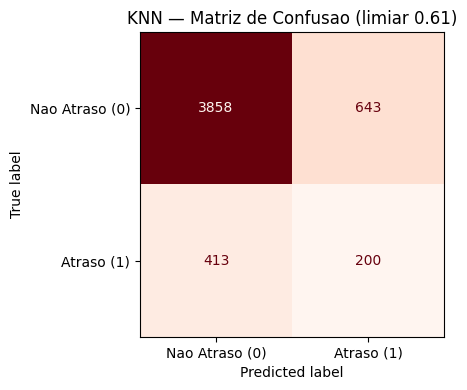

Resumo (teste):
- Limiar adotado: 0.61
- Precision atraso: 0.2372
- Recall atraso: 0.3263
- F1 atraso: 0.2747
- F2 atraso: 0.3035
- PR-AUC atraso: 0.2435


In [5]:
# Celula 5: treino final do KNN e avaliacao no teste.

# Reconstrucao dos parametros porque 'p' so faz sentido para Minkowski.
final_params = {
    "n_neighbors": best_params_knn["n_neighbors"],
    "weights": best_params_knn["weights"],
    "metric": best_params_knn["metric"],
    "leaf_size": best_params_knn["leaf_size"],
    "n_jobs": -1,
}
if best_params_knn["metric"] == "minkowski":
    final_params["p"] = best_params_knn.get("p", 2)

# =============================================================
# BALANCEAMENTO DO TREINO FINAL
# O conjunto de teste NAO e balanceado.
# =============================================================
rus_final = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus_final.fit_resample(X_train, y_train)

print("Distribuicao ANTES do balanceamento:")
print(y_train.value_counts().sort_index())
print("\nDistribuicao DEPOIS do balanceamento:")
print(pd.Series(y_train_bal).value_counts().sort_index())

model_knn = KNeighborsClassifier(**final_params)
model_knn.fit(X_train_bal, y_train_bal)

# Probabilidade de atraso (classe 1).
y_proba_knn_train = model_knn.predict_proba(X_train)[:, 1]
y_proba_knn_test = model_knn.predict_proba(X_test)[:, 1]

# Mesmo conceito usado no XGBoost: nao obrigamos limiar 0.50.
y_pred_knn_train = (y_proba_knn_train >= best_threshold_knn).astype(int)
y_pred_knn_test = (y_proba_knn_test >= best_threshold_knn).astype(int)

res_knn_train = metricas_atraso(
    y_train, y_pred_knn_train, y_proba_knn_train
)
res_knn_test = metricas_atraso(
    y_test, y_pred_knn_test, y_proba_knn_test
)

metricas_treino_knn = metricas_gerais(
    y_train, y_pred_knn_train, y_proba_knn_train
)
metricas_teste_knn = metricas_gerais(
    y_test, y_pred_knn_test, y_proba_knn_test
)

print("Metricas no teste (foco em atraso):")
display(pd.DataFrame(pd.Series(res_knn_test, name="Teste")).round(4))

print("\nComo interpretar as metricas:")
print("- precision_atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.")
print("- recall_atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.")
print("- f1_atraso: equilibrio entre precision e recall.")
print("- f2_atraso: da mais peso ao recall, ajudando a avaliar a deteccao de atrasos.")
print("- roc_auc_atraso: separacao entre atraso e nao atraso em varios limiares.")
print("- pr_auc_atraso: especialmente util quando atraso e uma classe rara.")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn_test,
    cmap="Reds",
    ax=ax,
    colorbar=False,
    display_labels=["Nao Atraso (0)", "Atraso (1)"],
)
ax.set_title(f"KNN — Matriz de Confusao (limiar {best_threshold_knn:.2f})")
plt.tight_layout()
plt.show()

print("Resumo (teste):")
print(f"- Limiar adotado: {best_threshold_knn:.2f}")
print(f"- Precision atraso: {res_knn_test['precision_atraso']:.4f}")
print(f"- Recall atraso: {res_knn_test['recall_atraso']:.4f}")
print(f"- F1 atraso: {res_knn_test['f1_atraso']:.4f}")
print(f"- F2 atraso: {res_knn_test['f2_atraso']:.4f}")
print(f"- PR-AUC atraso: {res_knn_test['pr_auc_atraso']:.4f}")


In [6]:
# Celula 6: tabelas finais de metricas.
print("=" * 120)
print("METRICAS DE ATRASO (CLASSE 1) — KNN")
print("=" * 120)

print("\n" + "-" * 120)
print("TREINO")
print("-" * 120)
df_knn_train_atraso = pd.DataFrame(pd.Series(res_knn_train, name="Treino"))
display(df_knn_train_atraso.round(4))

print("\n" + "-" * 120)
print("TESTE")
print("-" * 120)
df_knn_test_atraso = pd.DataFrame(pd.Series(res_knn_test, name="Teste"))
display(df_knn_test_atraso.round(4))

print("\nRESUMO")
print("─" * 120)
print(f"Limiar utilizado: {best_threshold_knn:.2f}")
print(
    f"Treino - Accuracy: {metricas_treino_knn['Accuracy']:.4f}, "
    f"ROC-AUC: {metricas_treino_knn['ROC-AUC']:.4f}, "
    f"Precision (Atraso): {res_knn_train['precision_atraso']:.4f}, "
    f"Recall (Atraso): {res_knn_train['recall_atraso']:.4f}, "
    f"F2 (Atraso): {res_knn_train['f2_atraso']:.4f}"
)
print(
    f"Teste  - Accuracy: {metricas_teste_knn['Accuracy']:.4f}, "
    f"ROC-AUC: {metricas_teste_knn['ROC-AUC']:.4f}, "
    f"Precision (Atraso): {res_knn_test['precision_atraso']:.4f}, "
    f"Recall (Atraso): {res_knn_test['recall_atraso']:.4f}, "
    f"F2 (Atraso): {res_knn_test['f2_atraso']:.4f}"
)


METRICAS DE ATRASO (CLASSE 1) — KNN

------------------------------------------------------------------------------------------------------------------------
TREINO
------------------------------------------------------------------------------------------------------------------------


,Treino
accuracy_atraso,0.9092
precision_atraso,0.3534
recall_atraso,1.0000
f1_atraso,0.5223
f2_atraso,0.7321
roc_auc_atraso,1.0000
pr_auc_atraso,1.0000
balanced_accuracy_atraso,0.9522
mcc_atraso,0.5654
brier_score_atraso,0.1719



------------------------------------------------------------------------------------------------------------------------
TESTE
------------------------------------------------------------------------------------------------------------------------


,Teste
accuracy_atraso,0.7935
precision_atraso,0.2372
recall_atraso,0.3263
f1_atraso,0.2747
f2_atraso,0.3035
roc_auc_atraso,0.7195
pr_auc_atraso,0.2435
balanced_accuracy_atraso,0.5917
mcc_atraso,0.1606
brier_score_atraso,0.2286



RESUMO
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Limiar utilizado: 0.61
Treino - Accuracy: 0.9092, ROC-AUC: 1.0000, Precision (Atraso): 0.3534, Recall (Atraso): 1.0000, F2 (Atraso): 0.7321
Teste  - Accuracy: 0.7935, ROC-AUC: 0.7195, Precision (Atraso): 0.2372, Recall (Atraso): 0.3263, F2 (Atraso): 0.3035


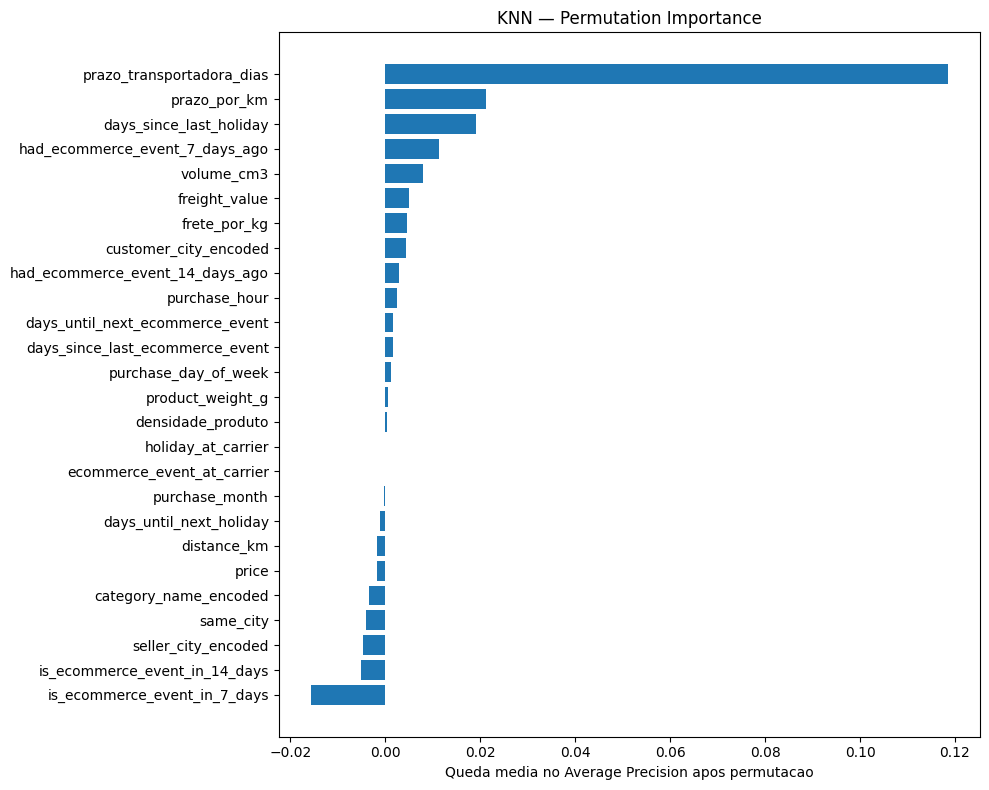

,feature,importance_mean,importance_std
18,prazo_transportadora_dias,0.118554,0.003894
20,prazo_por_km,0.021147,0.000778
1,days_since_last_holiday,0.019118,0.002699
8,had_ecommerce_event_7_days_ago,0.011411,0.002362
15,volume_cm3,0.007880,0.000456
13,freight_value,0.005076,0.002331
21,frete_por_kg,0.004525,0.005461
23,customer_city_encoded,0.004365,0.003869
9,had_ecommerce_event_14_days_ago,0.002963,0.001002
10,purchase_hour,0.002445,0.002136


In [7]:
# Celula 7: importancia das features por Permutation Importance.
# KNN nao possui Gain/Weight como o XGBoost.
# Permutation Importance mede quanto a qualidade cai quando uma feature e embaralhada.

# Limita a amostra para evitar custo excessivo em bases grandes.
rng = np.random.RandomState(42)
sample_size = min(5000, len(X_test))

if len(X_test) > sample_size:
    sample_idx = rng.choice(len(X_test), size=sample_size, replace=False)
    X_imp = X_test.iloc[sample_idx]
    y_imp = y_test.iloc[sample_idx]
else:
    X_imp = X_test
    y_imp = y_test

perm = permutation_importance(
    model_knn,
    X_imp,
    y_imp,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

df_imp_knn = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(df_imp_knn["feature"], df_imp_knn["importance_mean"])
plt.xlabel("Queda media no Average Precision apos permutacao")
plt.title("KNN — Permutation Importance")
plt.tight_layout()
plt.show()

display(df_imp_knn.sort_values("importance_mean", ascending=False).round(6))


In [8]:
# Celula 8: exportacao do KNN + objetos necessarios ao pre-processamento.

nome_arquivo_modelo = "knn_temporal_model_bundle.pkl"

bundle_knn = {
    "model": model_knn,
    "scaler": scaler,
    "threshold": best_threshold_knn,
    "feature_columns": X_train.columns.tolist(),
    "train_medians": train_medians.to_dict(),
    "target_encoding": {
        "media_global_atraso": float(media_global_atraso),
        "m": m,
        "customer_city": smooth_customer.to_dict(),
        "seller_city": smooth_seller.to_dict(),
        "category_name": smooth_cat.to_dict(),
    },
    "best_params": final_params,
    "balancing": {
        "method": "RandomUnderSampler",
        "random_state": 42,
        "applied_only_to_training": True,
    },
}

with open(nome_arquivo_modelo, "wb") as file:
    pickle.dump(bundle_knn, file)

print(f"[Exportacao] Bundle salvo com sucesso: '{nome_arquivo_modelo}'")

n_registros = 100
df_export = X_test.head(n_registros).copy()
df_export["target_real_atraso"] = y_test.head(n_registros).values
df_export["predicao_modelo"] = y_pred_knn_test[:n_registros]
df_export["probabilidade_atraso"] = y_proba_knn_test[:n_registros].round(4)

nome_arquivo_csv = f"amostra_teste_knn_{n_registros}_pedidos.csv"
df_export.to_csv(nome_arquivo_csv, index=False)
print(f"[Exportacao] Tabela de teste salva com sucesso: '{nome_arquivo_csv}'")


[Exportacao] Bundle salvo com sucesso: 'knn_temporal_model_bundle.pkl'
[Exportacao] Tabela de teste salva com sucesso: 'amostra_teste_knn_100_pedidos.csv'
